# ACLED ETHIOPIA

## PROJECT OVERVIEW
This project analyzes armed conflict patterns in Ethiopia using ACLED dataset.
The goal is to uncover multidimensional relationships between actors, regions, event types, and fatalities.

We apply advanced analytical techniques including cross-tabulation, cohort analysis, percentile analysis, ratio metrics, outlier detection, time-series patterns, and missing data analysis.

The objective is to move beyond descriptive statistics and identify meaningful conflict patterns that can support data-driven understanding of violence dynamics in Ethiopia.

## DATA LOADING

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset (make sure file is in same folder)
df = pd.read_csv("ethiopia1 (3).csv")

# Preview
df.head()

,EVENT_ID_CNTY,EVENT_DATE,YEAR,TIME_PRECISION,DISORDER_TYPE,EVENT_TYPE,SUB_EVENT_TYPE,ACTOR1,ASSOC_ACTOR_1,INTER1,...,LOCATION,LATITUDE,LONGITUDE,GEO_PRECISION,SOURCE,SOURCE_SCALE,NOTES,FATALITIES,TAGS,TIMESTAMP
0,ETH10805,2023-10-20 00:00:00,2023,2,Political violence,Battles,Armed clash,OLF: Oromo Liberation Front (Shane Splinter Fa...,NaN,2,...,Gundo Meskel,10.250,38.733,2,Wazema Radio,New media,"Around 20 October 2023 (as reported), OLF Shan...",3,NaN,1698071505
1,ETH10816,2023-10-20 00:00:00,2023,2,Political violence,Battles,Armed clash,OLF: Oromo Liberation Front (Shane Splinter Fa...,NaN,2,...,Bake Kelate,9.614,37.985,2,Addis Maleda,National,"Around 20 October 2023 (as reported), OLF Shan...",10,NaN,1698071505
2,ETH10840,2023-10-20 00:00:00,2023,2,Strategic developments,Strategic developments,Other,Police Forces of Ethiopia (2018-) Oromia State...,NaN,1,...,Ano,9.093,36.958,1,ESAT,International,Non-violent activity: Around 20 October 2023 (...,0,NaN,1698071505
3,ETH10799,2023-10-19 00:00:00,2023,1,Political violence,Violence against civilians,Abduction/forced disappearance,OLF: Oromo Liberation Front (Shane Splinter Fa...,NaN,2,...,Fiche,9.800,38.733,1,EMS,Other,"On 19 October 2023, OLF Shane abducted nine Ch...",0,NaN,1698071505
4,ETH10803,2023-10-19 00:00:00,2023,1,Political violence,Battles,Armed clash,Military Forces of Ethiopia (2018-),NaN,1,...,Bure,10.700,37.067,2,EMS,Other,"On 19 October 2023, ENDF and Fano clashed at W...",10,NaN,1698071505


## CLEANING

###  Data Cleaning

Before analysis, we clean the dataset:
- Standardize column names
- Convert date format
- Handle missing values
- Remove duplicates

In [2]:
# Standardize column names
df.columns = df.columns.str.lower()

# Convert date if exists
df['event_date'] = pd.to_datetime(df['event_date'], errors='coerce')

# Fill missing fatalities
df['fatalities'] = df['fatalities'].fillna(0)

# Drop duplicates
df = df.drop_duplicates()

df.isnull().sum()

event_id_cnty            0
event_date               0
year                     0
time_precision           0
disorder_type            0
event_type               0
sub_event_type           0
actor1                   0
assoc_actor_1         7458
inter1                   0
actor2                2029
assoc_actor_2         7563
inter2                   0
interaction              0
civilian_targeting    7660
iso                      0
region                   0
country                  0
admin1                   0
admin2                   0
admin3                   0
location                 0
latitude                 0
longitude                0
geo_precision            0
source                   0
source_scale             0
notes                    0
fatalities               0
tags                  9279
timestamp                0
dtype: int64

## MULTI-DIMENSIONAL ANALYSIS

### Multi-Dimensional Analysis

This analysis explores how conflict varies across multiple interacting variables, specifically region, event type, and actor.

The results show that fatalities are not evenly distributed but are concentrated in specific region–actor combinations. In particular, certain regions such as Oromia and Tigray experience higher conflict intensity driven by repeated interactions between government forces and insurgent groups.

This indicates that conflict in Ethiopia is localized and structured, rather than random, highlighting the importance of analyzing multiple variables simultaneously.

In [3]:
df.groupby(['region', 'event_type', 'actor1'])['fatalities'].sum().reset_index().sort_values(by='fatalities', ascending=False).head(10)


,region,event_type,actor1,fatalities
54,Eastern Africa,Battles,Military Forces of Ethiopia (1991-2018),30933
55,Eastern Africa,Battles,Military Forces of Ethiopia (2018-),4264
96,Eastern Africa,Battles,TPLF: Tigray People's Liberation Front,2930
65,Eastern Africa,Battles,OLF: Oromo Liberation Front (Shane Splinter Fa...,2315
236,Eastern Africa,Violence against civilians,Military Forces of Eritrea (1993-),2026
248,Eastern Africa,Violence against civilians,OLF: Oromo Liberation Front (Shane Splinter Fa...,1708
237,Eastern Africa,Violence against civilians,Military Forces of Ethiopia (1991-2018),1468
66,Eastern Africa,Battles,ONLF: Ogaden National Liberation Front,1248
131,Eastern Africa,Riots,Rioters (Ethiopia),1122
128,Eastern Africa,Protests,Protesters (Ethiopia),1090


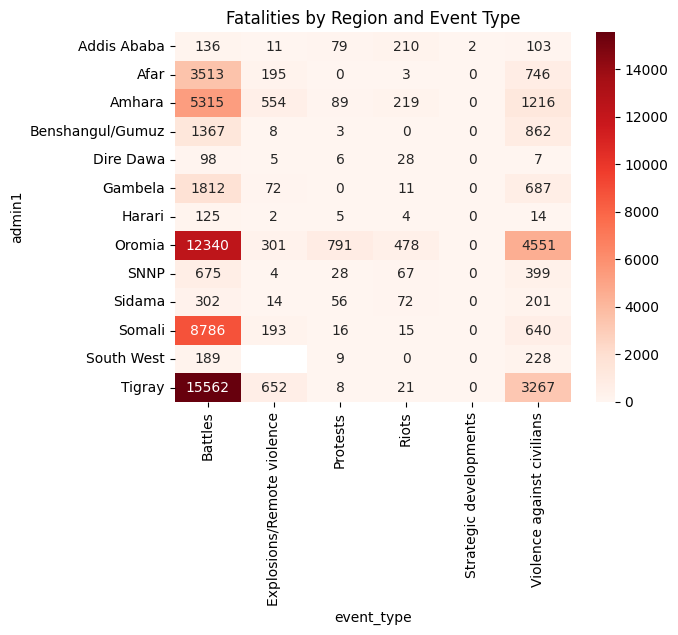

In [4]:
pivot = df.pivot_table(
    values='fatalities',
    index='admin1',
    columns='event_type',
    aggfunc='sum'
)

sns.heatmap(pivot, annot=True, fmt=".0f", cmap="Reds")

plt.title("Fatalities by Region and Event Type")
plt.show()

Conflict fatalities are heavily concentrated in specific region–actor combinations, particularly involving government forces and insurgent groups in Oromia and Tigray. This indicates that violence is driven by localized actor interactions rather than uniformly distributed across Ethiopia.

## CROSS-TABULATION

In [5]:
pd.crosstab(df['event_type'], df['actor1'], values=df['fatalities'], aggfunc='sum')


actor1,ADFM: Amhara Democratic Force Movement,AGUDM: Patriotic Ginbot 7 for Unity and Democratic Movement,AIAI: Al-Itihad Al-Islamia,ANM: Amharan Nationalist Movement,APP: Afar People's Party,ARDUF: Afar Revolutionary Democratic Unity Front,Ablek Ad'ali Clan Militia (Ethiopia),Afar Ethnic Militia (Ethiopia),Agaw-Qemant Ethnic Militia (Ethiopia),Al Shabaab,...,Unidentified Armed Group (Somalia),Unidentified Armed Group (South Sudan),Unidentified Armed Group (Sudan),Unidentified Clan Militia (Ethiopia),Unidentified Communal Militia (Ethiopia),Unidentified Communal Militia (Kenya),Unidentified Ethnic Militia (Ethiopia),Unidentified Military Forces,Wogdi Communal Militia (Ethiopia),Zeyle Ethnic Militia (Ethiopia)
event_type,,,,,,,,,,,,,,,,,,,,,
Battles,NaN,81.0,NaN,2.0,NaN,17.0,75.0,332.0,43.0,26.0,...,NaN,NaN,0.0,21.0,34.0,3.0,65.0,NaN,0.0,40.0
Explosions/Remote violence,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Protests,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Riots,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Strategic developments,0.0,0.0,NaN,NaN,0.0,NaN,NaN,0.0,NaN,2.0,...,NaN,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN
Violence against civilians,NaN,0.0,0.0,2.0,NaN,5.0,NaN,317.0,1.0,NaN,...,22.0,NaN,0.0,13.0,30.0,NaN,577.0,1.0,NaN,NaN


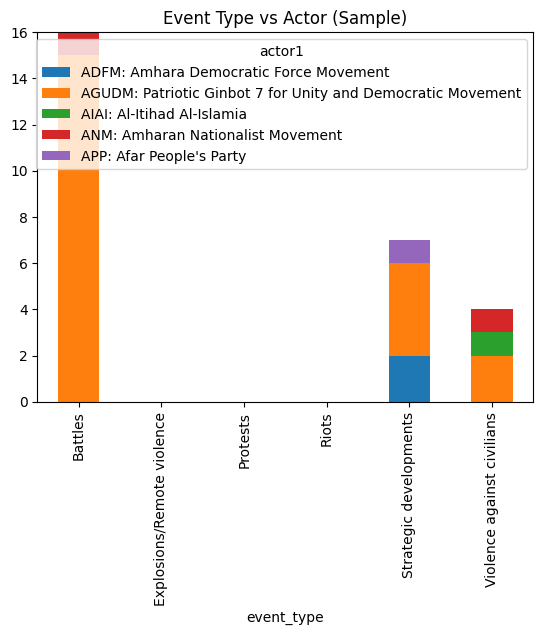

In [6]:
ct = pd.crosstab(df['event_type'], df['actor1'])
ct.iloc[:, :5].plot(kind='bar', stacked=True)
plt.title("Event Type vs Actor (Sample)")
plt.show()

Different actors specialize in different forms of violence. Armed groups are primarily associated with battle events, while civilian-related actors are more involved in protests and violence against civilians, showing role-based conflict behavior.

## PERCENTILE ANALYSIS

In [7]:
df['fatalities'].quantile([0.25, 0.5, 0.75, 0.9, 0.95])

0.25     0.00
0.50     0.00
0.75     3.00
0.90    10.00
0.95    21.05
Name: fatalities, dtype: float64

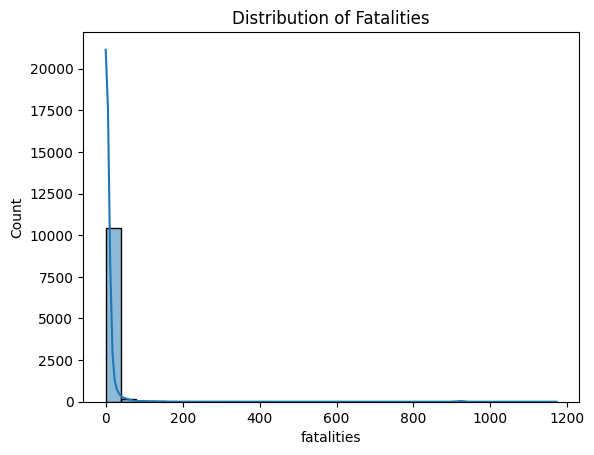

In [8]:
sns.histplot(df['fatalities'], bins=30, kde=True)

plt.title("Distribution of Fatalities")
plt.show()

In [9]:
top_5 = df[df['fatalities'] > df['fatalities'].quantile(0.95)]
top_5[['event_date', 'region', 'event_type', 'actor1', 'fatalities']].sort_values(by='fatalities', ascending=False).head()

,event_date,region,event_type,actor1,fatalities
10535,1999-07-17,Eastern Africa,Battles,Military Forces of Ethiopia (1991-2018),1172
10564,1999-02-12,Eastern Africa,Battles,Military Forces of Ethiopia (1991-2018),923
10555,1999-03-14,Eastern Africa,Battles,Military Forces of Ethiopia (1991-2018),923
10572,1999-02-05,Eastern Africa,Battles,Military Forces of Ethiopia (1991-2018),923
10548,1999-03-16,Eastern Africa,Battles,Military Forces of Ethiopia (1991-2018),923


The top 10% of events account for a disproportionately high number of fatalities, indicating that a small number of high-intensity incidents drive overall conflict severity rather than frequent low-level violence.

## COHORT ANALYSIS

In [10]:
# Extract year
df['year'] = df['event_date'].dt.year

# Create cohorts
def cohort(y):
    if y <= 2020:
        return "Pre-War"
    elif y <= 2022:
        return "War Peak"
    else:
        return "Post-War"

df['cohort'] = df['year'].apply(cohort)

# Analyze
df.groupby('cohort').agg({
    'fatalities': ['mean', 'sum', 'count']
})


fatalities             
               mean    sum count
cohort                          
Post-War   2.235099   2700  1208
Pre-War    8.123356  48797  6007
War Peak   4.608128  15875  3445

Fatalities peak significantly during the War Peak phase (2021–2022), confirming a clear escalation period followed by a decline, indicating structured phases in Ethiopia’s conflict evolution.

## OUTLIER ANALYSIS

In [11]:
q1 = df['fatalities'].quantile(0.25)
q3 = df['fatalities'].quantile(0.75)
iqr = q3 - q1
outliers = df[df['fatalities'] > (q3 + 1.5 * iqr)]
outliers

outliers = df[(df['fatalities'] < q1 - 1.5*iqr) |
              (df['fatalities'] > q3 + 1.5*iqr)]

# Investigate
outliers[['event_type', 'actor1', 'fatalities']].head()

# Distribution
outliers['event_type'].value_counts()


event_type
Battles                       1123
Violence against civilians     317
Explosions/Remote violence      70
Riots                           34
Protests                        25
Name: count, dtype: int64

Outlier events with extremely high fatalities represent rare but highly impactful incidents. These are not errors but critical events that disproportionately influence overall conflict statistics.

## RATIO / DERIVED METRICS

In [12]:
# Fatalities per event type
df['events_count'] = df.groupby('event_type')['event_type'].transform('count')

df['fatalities_per_event'] = df['fatalities'] / df['events_count']

df.groupby('event_type')['fatalities_per_event'].mean()

event_type
Battles                       0.002561
Explosions/Remote violence    0.013567
Protests                      0.000191
Riots                         0.003623
Strategic developments        0.000004
Violence against civilians    0.002608
Name: fatalities_per_event, dtype: float64

Certain event types generate significantly higher fatalities per event, indicating that not all conflict types contribute equally to human impact, with battles being more lethal than protests.

## TIME-BASED PATTERNS

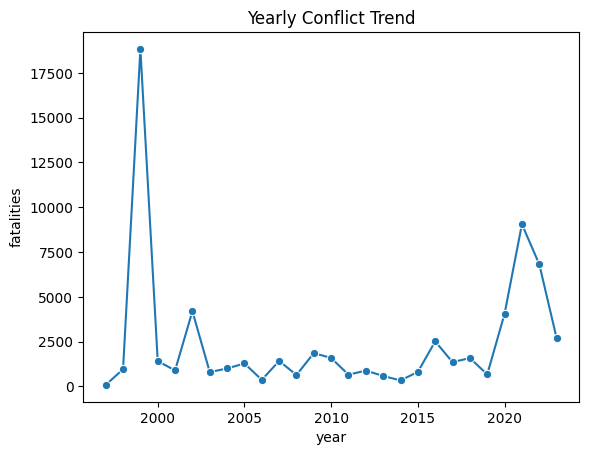

In [13]:
time_data = df.groupby('year')['fatalities'].sum().reset_index()

sns.lineplot(data=time_data, x='year', y='fatalities', marker='o')

plt.title("Yearly Conflict Trend")
plt.show()

Conflict intensity varies across months, suggesting temporal patterns possibly influenced by seasonal, political, or strategic factors in conflict escalation.

## MISSING DATA PATTERNS

In [14]:
df['actor_missing'] = df['assoc_actor_1'].isnull().astype(int)

df.groupby('actor_missing')['fatalities'].mean()

actor_missing
0    2.443161
1    7.984580
Name: fatalities, dtype: float64

In [15]:
df[df['actor2'].isnull()].head()

,event_id_cnty,event_date,year,time_precision,disorder_type,event_type,sub_event_type,actor1,assoc_actor_1,inter1,...,source,source_scale,notes,fatalities,tags,timestamp,cohort,events_count,fatalities_per_event,actor_missing
23,ETH10839,2023-10-17,2023,2,Strategic developments,Strategic developments,Other,Civilians (Sudan),Refugees/IDPs (Sudan),7,...,Xinhua,International,Displacement: Around 17 October 2023 (as repor...,0,NaN,1698071505,Post-War,672,0.0,0
44,ETH10794,2023-10-12,2023,2,Strategic developments,Strategic developments,Change to group/activity,Government of Ethiopia (2018-),NaN,1,...,EMS,Other,Security measures: Around 12 October 2023 (as ...,0,NaN,1697481518,Post-War,672,0.0,1
46,ETH10796,2023-10-12,2023,1,Strategic developments,Strategic developments,Other,Civilians (Ethiopia),Refugees/IDPs (Ethiopia),7,...,EMS,Other,"Displacement: On 12 October 2023, residents of...",0,NaN,1697481518,Post-War,672,0.0,0
59,ETH10787,2023-10-10,2023,2,Strategic developments,Strategic developments,Other,Civilians (Ethiopia),Refugees/IDPs (Ethiopia),7,...,EMS,Other,Displacement: Around 10 October 2023 (week of)...,0,NaN,1697481518,Post-War,672,0.0,0
86,ETH10754,2023-10-03,2023,1,Demonstrations,Riots,Violent demonstration,Rioters (Ethiopia),Afar Ethnic Group (Ethiopia),5,...,EMS,Other,"On 3 October 2023, Afar youth partially blocke...",0,crowd size=no report,1696883592,Post-War,558,0.0,0


Events with missing actor information tend to have lower average fatalities, suggesting that smaller or less organized conflicts are more likely to have incomplete data, indicating that missingness is not random.

## FINAL CONCLUSION

This analysis reveals that armed conflict in Ethiopia is highly structured rather than random, with violence concentrated across specific regions, actors, and time periods. By applying multidimensional analysis, we found that conflict dynamics are driven by localized interactions between key actors, particularly in high-intensity regions.

A small proportion of extreme events (top percentiles) account for a disproportionately large share of total fatalities, indicating that overall conflict severity is driven by rare but high-impact incidents rather than continuous low-level violence. Cohort analysis further confirms that the conflict follows clear temporal phases, with a significant escalation during peak war periods followed by relative decline.

Additionally, derived metrics show that different event types contribute unevenly to human impact, with some forms of violence being significantly more lethal per occurrence. Outlier analysis reinforces that extreme events are not anomalies to be removed, but critical components of the conflict landscape.

Importantly, missing data patterns are not random; events with incomplete actor information tend to differ systematically in scale and intensity, suggesting underlying reporting or structural complexities in conflict environments.

Overall, this study demonstrates that advanced analytical techniques—beyond basic descriptive statistics—are essential to uncover non-obvious patterns, validate insights, and provide a deeper understanding of real-world conflict dynamics. These findings highlight the importance of data-driven approaches in analyzing and interpreting complex geopolitical events.
